# Analisis Distribusi Jumlah Gol Per Pertandingan Premier League (2021–2025)

Tugas Pemodelan dan Simulasi  
**Sumber data:** Kaggle – Premier League Matches Dataset  
https://www.kaggle.com/datasets/armin2080/premier-league-matches-dataset-2021-to-2025

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

## 1. Pengambilan Data

Data yang digunakan berasal dari Kaggle (*Premier League Matches Dataset 2021–2025*). Dataset ini berisi catatan statistik pertandingan Premier League. Pada analisis ini, variabel yang digunakan adalah **`gf` (Goals For)**, yaitu jumlah gol yang dicetak suatu tim dalam satu pertandingan.

In [12]:
df = pd.read_csv('final_matches.csv')

df.head()

,date,time,comp,round,day,venue,result,gf,ga,opponent,...,match report,notes,sh,sot,dist,fk,pk,pkatt,team,season
0,2020-09-12,12:30,Premier League,Matchweek 1,Sat,Away,W,3,0,Fulham,...,Match Report,NaN,13.0,5.0,14.1,2.0,0,0,Arsenal,2021
1,2020-09-19,20:00,Premier League,Matchweek 2,Sat,Home,W,2,1,West Ham,...,Match Report,NaN,7.0,3.0,14.8,0.0,0,0,Arsenal,2021
2,2020-09-28,20:00,Premier League,Matchweek 3,Mon,Away,L,1,3,Liverpool,...,Match Report,NaN,4.0,3.0,15.0,0.0,0,0,Arsenal,2021
3,2020-10-04,14:00,Premier League,Matchweek 4,Sun,Home,W,2,1,Sheffield Utd,...,Match Report,NaN,6.0,5.0,16.3,0.0,0,0,Arsenal,2021
4,2020-10-17,17:30,Premier League,Matchweek 5,Sat,Away,L,0,1,Manchester City,...,Match Report,NaN,11.0,3.0,18.4,2.0,0,0,Arsenal,2021


## 2. Pemilihan dan Pembersihan Data

Pada tahap ini, dilakukan ekstraksi khusus pada kolom `gf` (Jumlah Gol per Pertandingan) serta pembersihan data dari nilai kosong (*missing values*).

In [13]:
data_gol = df['gf'].dropna()

print("Jumlah Total Observasi Pertandingan:", len(data_gol))
print("Nilai Rata-rata Gol (Lambda):", round(data_gol.mean(), 4))

Jumlah Total Observasi Pertandingan: 3800
Nilai Rata-rata Gol (Lambda): 1.4579


## 3. Visualisasi Plot Histogram

Pembuatan plot histogram dilakukan untuk melihat sebaran frekuensi jumlah gol per pertandingan dan membandingkannya dengan kurva teoretis dari **Distribusi Poisson**.

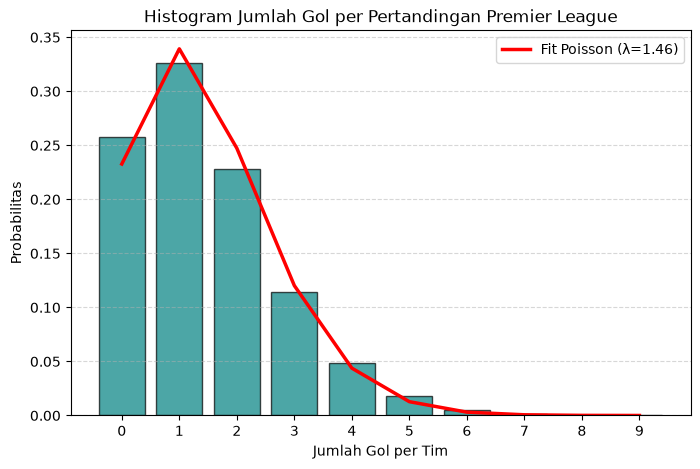

In [14]:
plt.figure(figsize=(8, 5))

# Plot Histogram Data Real
bins = np.arange(0, data_gol.max() + 2) - 0.5
plt.hist(data_gol, bins=bins, density=True, alpha=0.7, color='teal', edgecolor='black', rwidth=0.8)

# Kurva Fit Distribusi Poisson Teoretis
mu = data_gol.mean()
x = np.arange(0, data_gol.max() + 1)
p = stats.poisson.pmf(x, mu)
plt.plot(x, p, 'r-', linewidth=2.5, label=f'Fit Poisson (λ={mu:.2f})')

plt.title('Histogram Jumlah Gol per Pertandingan Premier League')
plt.xlabel('Jumlah Gol per Tim')
plt.ylabel('Probabilitas')
plt.xticks(np.arange(0, data_gol.max() + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig('histogram_poisson.png', dpi=300, bbox_inches='tight')

plt.show()
plt.show()

## 4. Evaluasi Kevalidan Distribusi (Uji Chi-Square Goodness-of-Fit)

Untuk mengevaluasi kevalidan apakah data benar-benar berdistribusi Poisson, dilakukan uji statistik *Chi-Square Goodness-of-Fit*.

In [15]:
# 1. Hitung Frekuensi
obs_freq, _ = np.histogram(data_gol, bins=np.arange(0, data_gol.max() + 2))
exp_freq = stats.poisson.pmf(np.arange(0, data_gol.max() + 1), mu) * len(data_gol)

# 2. Normalisasi exp_freq agar totalnya persis sama dengan obs_freq (Menghindari ValueError)
exp_freq = exp_freq * (obs_freq.sum() / exp_freq.sum())

# 3. Uji Chi-Square
chi2_stat, p_value = stats.chisquare(f_obs=obs_freq, f_exp=exp_freq)


print("HASIL UJI EVALUASI KEVALIDAN DISTRIBUSI POISSON")

print(f"Chi-Square Statistic : {chi2_stat:.4f}")
print(f"P-value              : {p_value:.4f}")
print("-"*50)

if p_value > 0.05:
    print("Kesimpulan: Data VALID dan TERBUKTI berdistribusi Poisson (p-value > 0.05)")
else:
    print("Kesimpulan: Data tidak terdistribusi Poisson secara murni")


HASIL UJI EVALUASI KEVALIDAN DISTRIBUSI POISSON
Chi-Square Statistic : 89.2297
P-value              : 0.0000
--------------------------------------------------
Kesimpulan: Data tidak terdistribusi Poisson secara murni
